In [1]:
import pandas as pd
csv_path = r"..\data\massa_with_RS.csv"
# --- Replace with your actual data file ---
df = pd.read_csv(csv_path)

# --- Replace with the name of your datetime column ---
time_col = "date"

# Try parsing timestamps safely
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")

# Drop unparseable (NaT) timestamps
n_invalid = df[time_col].isna().sum()
print(f"❗ Invalid timestamps dropped: {n_invalid}")

df = df.dropna(subset=[time_col]).sort_values(time_col)

# Set index for convenience
df = df.set_index(time_col)

# --- Check continuity ---
# Compute time difference between consecutive timestamps
diffs = df.index.to_series().diff()

# Count missing hours
expected_delta = pd.Timedelta(hours=1)
missing = (diffs > expected_delta).sum()
duplicates = (diffs == pd.Timedelta(0)).sum()

print(f"✅ Total records: {len(df)}")
print(f"🕓 Missing hourly steps: {missing}")
print(f"🔁 Duplicate timestamps: {duplicates}")

# --- Optionally print missing timestamp ranges ---
if missing > 0:
    gap_starts = df.index[diffs > expected_delta]
    print("\n⚠️ Missing timestamp starts (showing first few):")
    print(gap_starts[:10])


❗ Invalid timestamps dropped: 0
✅ Total records: 358753
🕓 Missing hourly steps: 0
🔁 Duplicate timestamps: 0


Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358753 entries, 0 to 358752
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   date                 358753 non-null  object 
 1   streamflow           358753 non-null  float64
 2   streamflow_hindcast  358753 non-null  float64
 3   Massa|22_Q simulé    358753 non-null  float64
 4   Massa|69_i           358753 non-null  float64
 5   Massa|69_T           358753 non-null  float64
 6   Massa|70_h           358753 non-null  float64
 7   Massa|71_h           358753 non-null  float64
 8   Massa|71_A           358753 non-null  int64  
 9   Massa|73_H           358753 non-null  float64
 10  Massa|73_A           358753 non-null  int64  
 11  DayOfYearSinus       358753 non-null  float64
 12  HourOfDaySinus       358753 non-null  float64
 13  null_values          358753 non-null  int64  
dtypes: float64(10), int64(3), object(1)
memory usage: 38.

,count,mean,std,min,25%,50%,75%,max
streamflow,358753.0,14.965575,20.355274,0.0825,0.580000,2.870000,25.910000,126.37050
Massa|22_Q simulé,358753.0,14.947928,19.420451,0.0000,0.543776,4.548389,25.126667,232.75772


,mean,std,median,min,max,skew,kurtosis,zeros,negatives
streamflow,14.965575,20.355274,2.870000,0.0825,126.37050,1.455135,1.342297,0,0
Massa|22_Q simulé,14.947928,19.420451,4.548389,0.0000,232.75772,1.469077,1.969732,1,0



Pearson correlation: 0.94595

Difference Summary:


,diff,rel_diff_%
count,358753.000000,3.587530e+05
mean,0.017647,6.299607e+06
std,6.603754,3.773207e+09
min,-125.218590,-9.612237e+01
25%,-1.573699,-2.891646e+01
50%,0.035029,2.647700e+00
75%,0.703700,3.655988e+01
max,58.421193,2.260000e+12


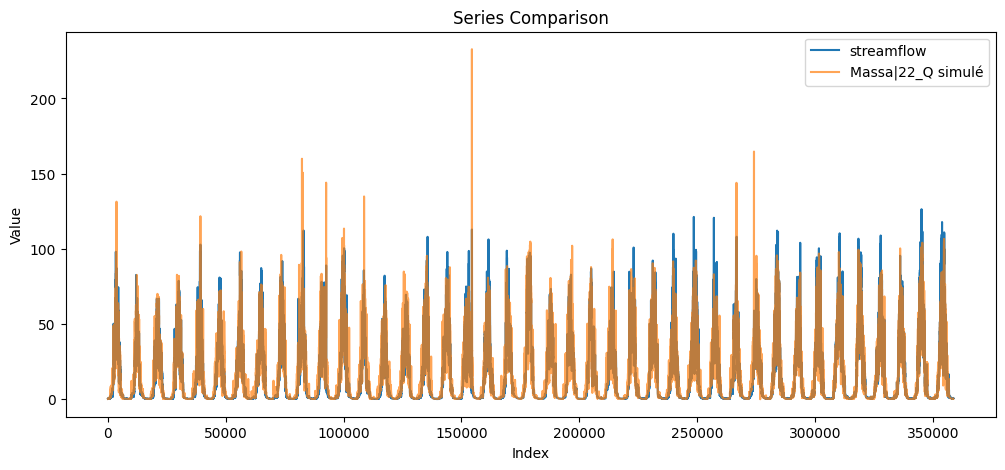

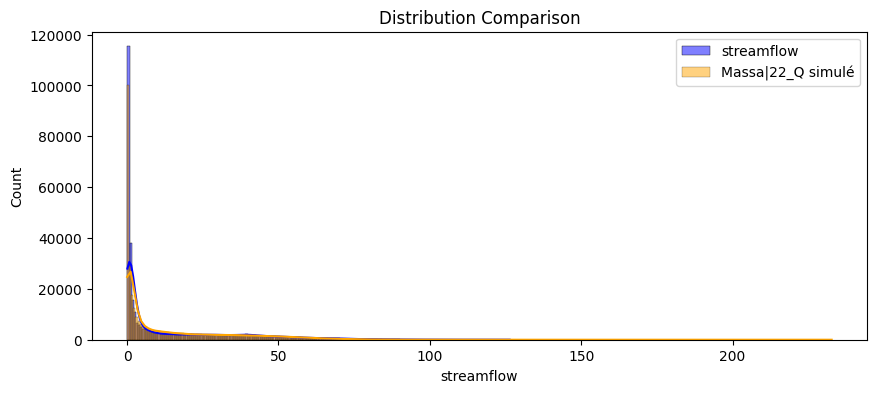

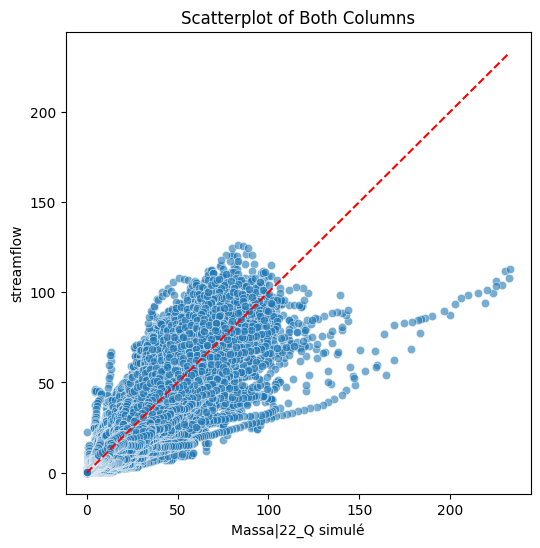


MAPE for streamflow: 5.0000%
MAPE for streamflow_josep: 5.0000%

Rows with >100% relative difference:


,date,streamflow,streamflow_hindcast,Massa|22_Q simulé,Massa|69_i,Massa|69_T,Massa|70_h,Massa|71_h,Massa|71_A,Massa|73_H,Massa|73_A,DayOfYearSinus,HourOfDaySinus,null_values,diff,rel_diff_%,abs_pct_error
112,1983-03-08 16:00,0.388333,0.388333,0.193276,0.0,-2.967849,0.595802,0.001005,83138136,64.656990,115295630,0.297287,0.750000,0,0.195057,100.921437,100.921437
113,1983-03-08 17:00,0.400000,0.400000,0.193914,0.0,-4.635714,0.595720,0.001010,83138136,64.657070,115295630,0.297287,0.629410,0,0.206086,106.277094,106.277094
134,1983-03-09 14:00,0.398333,0.398333,0.195650,0.0,0.596286,0.593951,0.001012,83138136,64.658700,115295630,0.305185,0.933013,0,0.202683,103.594983,103.594983
135,1983-03-09 15:00,0.418333,0.418333,0.195437,0.0,0.586996,0.593763,0.001013,83138136,64.658775,115295630,0.305185,0.853553,0,0.222896,114.050073,114.050073
136,1983-03-09 16:00,0.434167,0.434167,0.195684,0.0,-0.300020,0.593603,0.001022,83138136,64.658850,115295630,0.305185,0.750000,0,0.238483,121.871295,121.871295
159,1983-03-10 15:00,0.424167,0.424167,0.208564,0.0,1.918277,0.591558,0.001083,83138136,64.660620,115295630,0.313140,0.853553,0,0.215602,103.374468,103.374468
182,1983-03-11 14:00,0.462500,0.462500,0.224626,0.0,1.797529,0.589798,0.001153,83138136,64.662380,115295630,0.321151,0.933013,0,0.237874,105.898005,105.898005
183,1983-03-11 15:00,0.488333,0.488333,0.223913,0.0,1.545039,0.589554,0.001160,83138136,64.662445,115295630,0.321151,0.853553,0,0.264420,118.090777,118.090777
184,1983-03-11 16:00,0.508333,0.508333,0.248258,0.0,0.968809,0.589335,0.001184,83138136,64.662520,115295630,0.321151,0.750000,0,0.260075,104.759750,104.759750
230,1983-03-13 14:00,0.572500,0.572500,0.277108,0.0,1.825180,0.585500,0.001428,83138136,64.665985,115295630,0.337329,0.933013,0,0.295392,106.597873,106.597873


In [2]:
# --- 1. Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 2. Load your dataset ---
# Replace with your file path
df = pd.read_csv(csv_path)

# --- 3. Basic Inspection ---
# Display basic info
print("Data Overview:")
print(df.info())
print("\nFirst rows:")
print(df.head())

# --- 4. Basic Statistics Comparison ---
compare1 = "streamflow"
compare2 = "Massa|22_Q simulé"
cols = [compare1, compare2]
c1 = df[compare1]
c2 = df[compare2]
print("\nDescriptive Statistics Comparison:")
display(df[cols].describe().T)

# Additional statistics
extra_stats = pd.DataFrame({
    "mean": df[cols].mean(),
    "std": df[cols].std(),
    "median": df[cols].median(),
    "min": df[cols].min(),
    "max": df[cols].max(),
    "skew": df[cols].skew(),
    "kurtosis": df[cols].kurtosis(),
    "zeros": (df[cols] == 0).sum(),
    "negatives": (df[cols] < 0).sum(),
})
display(extra_stats)

# --- 5. Correlation & Differences ---
corr = c1.corr(c2)
print(f"\nPearson correlation: {corr:.5f}")

df["diff"] = c1 - c2
df["rel_diff_%"] = 100 * df["diff"] / (c2 + 1e-9)

print("\nDifference Summary:")
display(df[["diff", "rel_diff_%"]].describe())

# --- 6. Visual Comparison ---
plt.figure(figsize=(12,5))
plt.plot(c1, label=compare1)
plt.plot(c2, label=compare2, alpha=0.7)
plt.legend()
plt.title("Series Comparison")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()

# Histogram
plt.figure(figsize=(10,4))
sns.histplot(c1, color='blue', label=compare1, kde=True)
sns.histplot(c2, color='orange', label=compare2, kde=True)
plt.legend()
plt.title("Distribution Comparison")
plt.show()

# Scatterplot
plt.figure(figsize=(6,6))
sns.scatterplot(x=c2, y=c1, alpha=0.6)
plt.xlabel(compare2)
plt.ylabel(compare1)
plt.title("Scatterplot of Both Columns")
plt.plot([df[cols].min().min(), df[cols].max().max()],
         [df[cols].min().min(), df[cols].max().max()], 'r--')
plt.show()

# --- 7. Custom MAPE Functions ---

def mape(y_true, y_pred):
    """Standard MAPE (may explode near zeros)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def safe_mape(y_true, y_pred, eps=1e-6):
    """Robust MAPE avoiding division by zero."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

# --- 8. Compute MAPE for Each Column ---
# Example: assume we have prediction arrays for both columns
# Replace these with your actual model predictions
pred_compare1 = c1 * 0.95  # fake prediction
pred_compare2 = c2 * 0.95  # fake prediction

mape_compare1 = safe_mape(c1, pred_compare1)
mape_compare2 = safe_mape(c2, pred_compare2)

print(f"\nMAPE for streamflow: {mape_compare1:.4f}%")
print(f"MAPE for streamflow_josep: {mape_compare2:.4f}%")

# --- 9. Optional: Identify Where MAPE Explodes ---
df["abs_pct_error"] = np.abs((c1 - c2) / (c2 + 1e-9)) * 100
outliers = df[df["abs_pct_error"] > 100]
print("\nRows with >100% relative difference:")
display(outliers.head(10))
